In [69]:
%load_ext autoreload
%autoreload 2 
import numpy as np 
import shap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from Preprocess import preprocess_data
from xgboost import XGBRegressor
from xgboost.callback import EarlyStopping
from sklearn.metrics import mean_absolute_error
import optuna

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [70]:
data_orig = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
filtered_time = pd.read_csv("../filtered_time_to_next_event.csv")
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols, amount_of_known = preprocess_data(filtered_time, data_orig)

0        True
1        True
2        True
3        True
4        True
        ...  
5145     True
5146     True
5147     True
5148     True
5149    False
Name: time_to_next_ev_hr, Length: 5150, dtype: bool
(4941, 3)
(4941, 8)
(5150, 8)


In [71]:
# XGBoost


#Tuning XGBoost through the Optuna library
def objective(trial):
  XGBoost = XGBRegressor(
      objective="reg:squarederror",
      n_estimators=1000,
      learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1, log=True), #sweeping 0.01 to 0.1 in the log scale for optimal learning rate
      max_depth=trial.suggest_int("max_depth",2,5), #checking max depth between 2 and 5
      subsample=trial.suggest_float("subsample",0.6,0.9), #sweeping subsample possibilites between 0.6 and 0.9
      colsample_bytree=trial.suggest_float("colsample_bytree",0.6,0.9), #sweeping bytree parameters between 0.6 and 0.9
      random_state=42
  )
  XGBoost.fit(
      X_train, y_train, eval_set=[(X_val, y_val)], verbose=False) #To see more model info set verbose=True
  predictions= XGBoost.predict(X_val)
  RMSE = root_mean_squared_error(y_val, predictions)
  return RMSE

optimization = optuna.create_study(direction="minimize") #Finding the parameters that minimize the MAE
optimization.optimize(objective, n_trials=30) #Keeping at 30 to prevent overfitting with noise

#Showing what the parameters are
optimal_params = optimization.best_params
print("Optimal Parameters:", optimal_params)

#Running the XGBoost with the optimal parameters
XGBoost = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    **optimal_params,
    random_state=42,
)

XGBoost.fit(
    X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

#Calculating multiplicative error for XGBoost
XGBoost_Prediction = XGBoost.predict(X_test)
XGBoost_RMSE = root_mean_squared_error(y_test, XGBoost_Prediction)
XGBoost_Error = XGBoost_RMSE
print("XGBoost Error:", XGBoost_Error)

XGBoost_RMSE = mean_absolute_error(y_test, XGBoost_Prediction)
XGBoost_Error_MAE = XGBoost_RMSE
print("Mean XGBoost Error:", XGBoost_Error_MAE)

[I 2026-01-31 10:36:27,946] A new study created in memory with name: no-name-6798d2f4-f91f-4c0a-8b2e-b41473773c9a
[I 2026-01-31 10:36:28,508] Trial 0 finished with value: 21487.758361602682 and parameters: {'learning_rate': 0.09018242111705446, 'max_depth': 2, 'subsample': 0.8562403102585494, 'colsample_bytree': 0.866543216986577}. Best is trial 0 with value: 21487.758361602682.
[I 2026-01-31 10:36:29,188] Trial 1 finished with value: 21307.677917323035 and parameters: {'learning_rate': 0.027397814626806887, 'max_depth': 4, 'subsample': 0.7800416990812842, 'colsample_bytree': 0.6914461541109276}. Best is trial 1 with value: 21307.677917323035.
[I 2026-01-31 10:36:29,812] Trial 2 finished with value: 21363.063228775787 and parameters: {'learning_rate': 0.02971556149204641, 'max_depth': 3, 'subsample': 0.8496158772818706, 'colsample_bytree': 0.6975315061674723}. Best is trial 1 with value: 21307.677917323035.
[I 2026-01-31 10:36:30,445] Trial 3 finished with value: 21447.711711407985 and

Optimal Parameters: {'learning_rate': 0.010208469171748719, 'max_depth': 4, 'subsample': 0.7870053605638648, 'colsample_bytree': 0.7469266184576825}
XGBoost Error: 24419.29906654696
Mean XGBoost Error: 19382.1389088568


Sample0: True = 83970.00s, Predicted = 66268.54s, Error=17701.46s
Sample1: True = 87270.00s, Predicted = 32865.46s, Error=54404.54s
Sample2: True = 33150.00s, Predicted = 33056.22s, Error=93.78s
Sample3: True = 63240.00s, Predicted = 59136.39s, Error=4103.61s
Sample4: True = 83475.00s, Predicted = 66818.35s, Error=16656.65s
Sample5: True = 30930.00s, Predicted = 30980.52s, Error=50.52s
Sample6: True = 64215.00s, Predicted = 58701.52s, Error=5513.48s
Sample7: True = 80820.00s, Predicted = 60759.82s, Error=20060.18s
Sample8: True = 29430.00s, Predicted = 54154.98s, Error=24724.98s
Sample9: True = 57720.00s, Predicted = 55741.94s, Error=1978.06s
Sample10: True = 86460.00s, Predicted = 57119.61s, Error=29340.39s
Sample11: True = 40245.00s, Predicted = 56237.13s, Error=15992.13s
Sample12: True = 48015.00s, Predicted = 56354.90s, Error=8339.90s
Sample13: True = 84210.00s, Predicted = 50974.66s, Error=33235.34s
Sample14: True = 51780.00s, Predicted = 48743.07s, Error=3036.93s
Sample15: True =

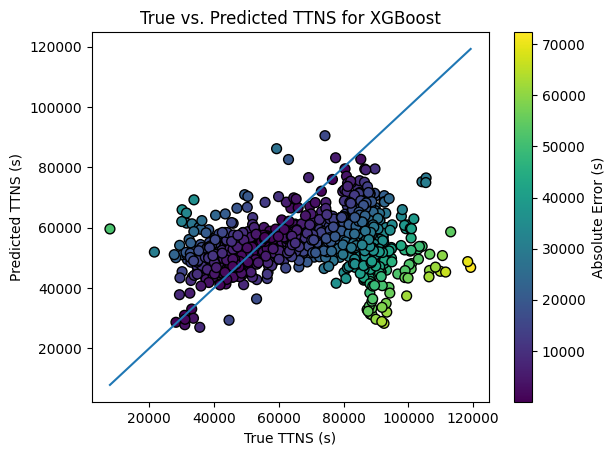

In [72]:
#XGBoost Analysis

#Taking the target column and predictions out of the log scale to calculate the average error in seconds
y_test_secs = y_test
XG_pred_secs = XGBoost_Prediction

absolute_error_secs_XG = np.abs(XG_pred_secs - y_test_secs)

#printing the true vs predicted value and error in seconds for every recrod
for i, (true, pred, abs_error) in enumerate(zip(y_test_secs, XG_pred_secs, absolute_error_secs_XG)):
  print(f"Sample{i}: True = {true:.2f}s, Predicted = {pred:.2f}s, Error={abs_error:.2f}s")

# Scatter plot of predicted vs true
plt.figure()
plt.scatter(y_test_secs, XG_pred_secs, c=absolute_error_secs_XG, cmap='viridis', s=50, edgecolors="black")
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_secs), max(y_test_secs)], [min(y_test_secs), max(y_test_secs)])
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for XGBoost")
#plt.xscale('log')
#plt.yscale('log')
plt.show()

 98%|===================| 965/989 [00:15<00:00]        

XG Boost Drivers: form_fac       2842.879367
time_since     2617.738405
tide_height    2248.904221
slip_size      1873.036989
tide_deriv     1686.901333
high_t_evt      204.254639
dtype: float64


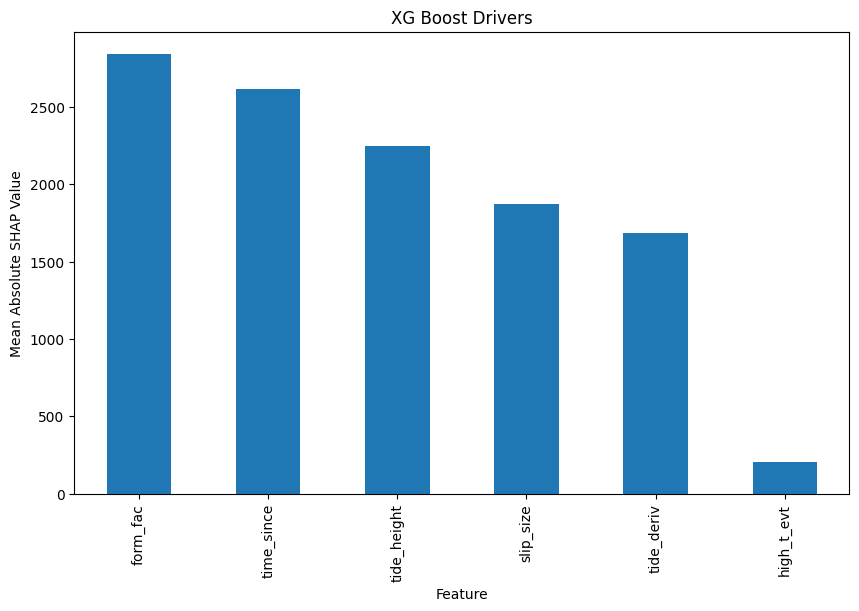

In [73]:
# Driving parameters for XG 

#Using the shap library with a copy of the training data to find the driving parameters
X_shap = X_test.copy()
explainer_XG = shap.TreeExplainer(XGBoost, X_shap, feature_perturbation="interventional") #Using interventional to respect correlation between the features

shap_values_XG = explainer_XG.shap_values(X_shap) #Doing the tree analysis on XG using training data

XG_imp = pd.Series(np.abs(shap_values_XG).mean(axis=0), index=X_shap.columns).sort_values(ascending=False) #Analysis of driving parameters in XG

print("XG Boost Drivers:", XG_imp)

# Creating a bar graph showing the driving parameters for XGBoost 
plt.figure(figsize=(10, 6))
XG_imp.sort_values(ascending=False).plot(kind="bar")
plt.title("XG Boost Drivers")
plt.ylabel("Mean Absolute SHAP Value")
plt.xlabel("Feature")
plt.show()
